In [1]:
%pip install pandas
#%pip install scikit-learn
#%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.tree import export_text
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error

In [3]:
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS','RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
df = pd.read_csv("Dataset/boston_housing.csv", header=None, delimiter=r"\s+", names=column_names)
df.head()


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [4]:
df.isna().sum().sum() # no existen valores nulos en el dataset.

np.int64(0)

In [ ]:
df.info()

In [ ]:
df.describe().T

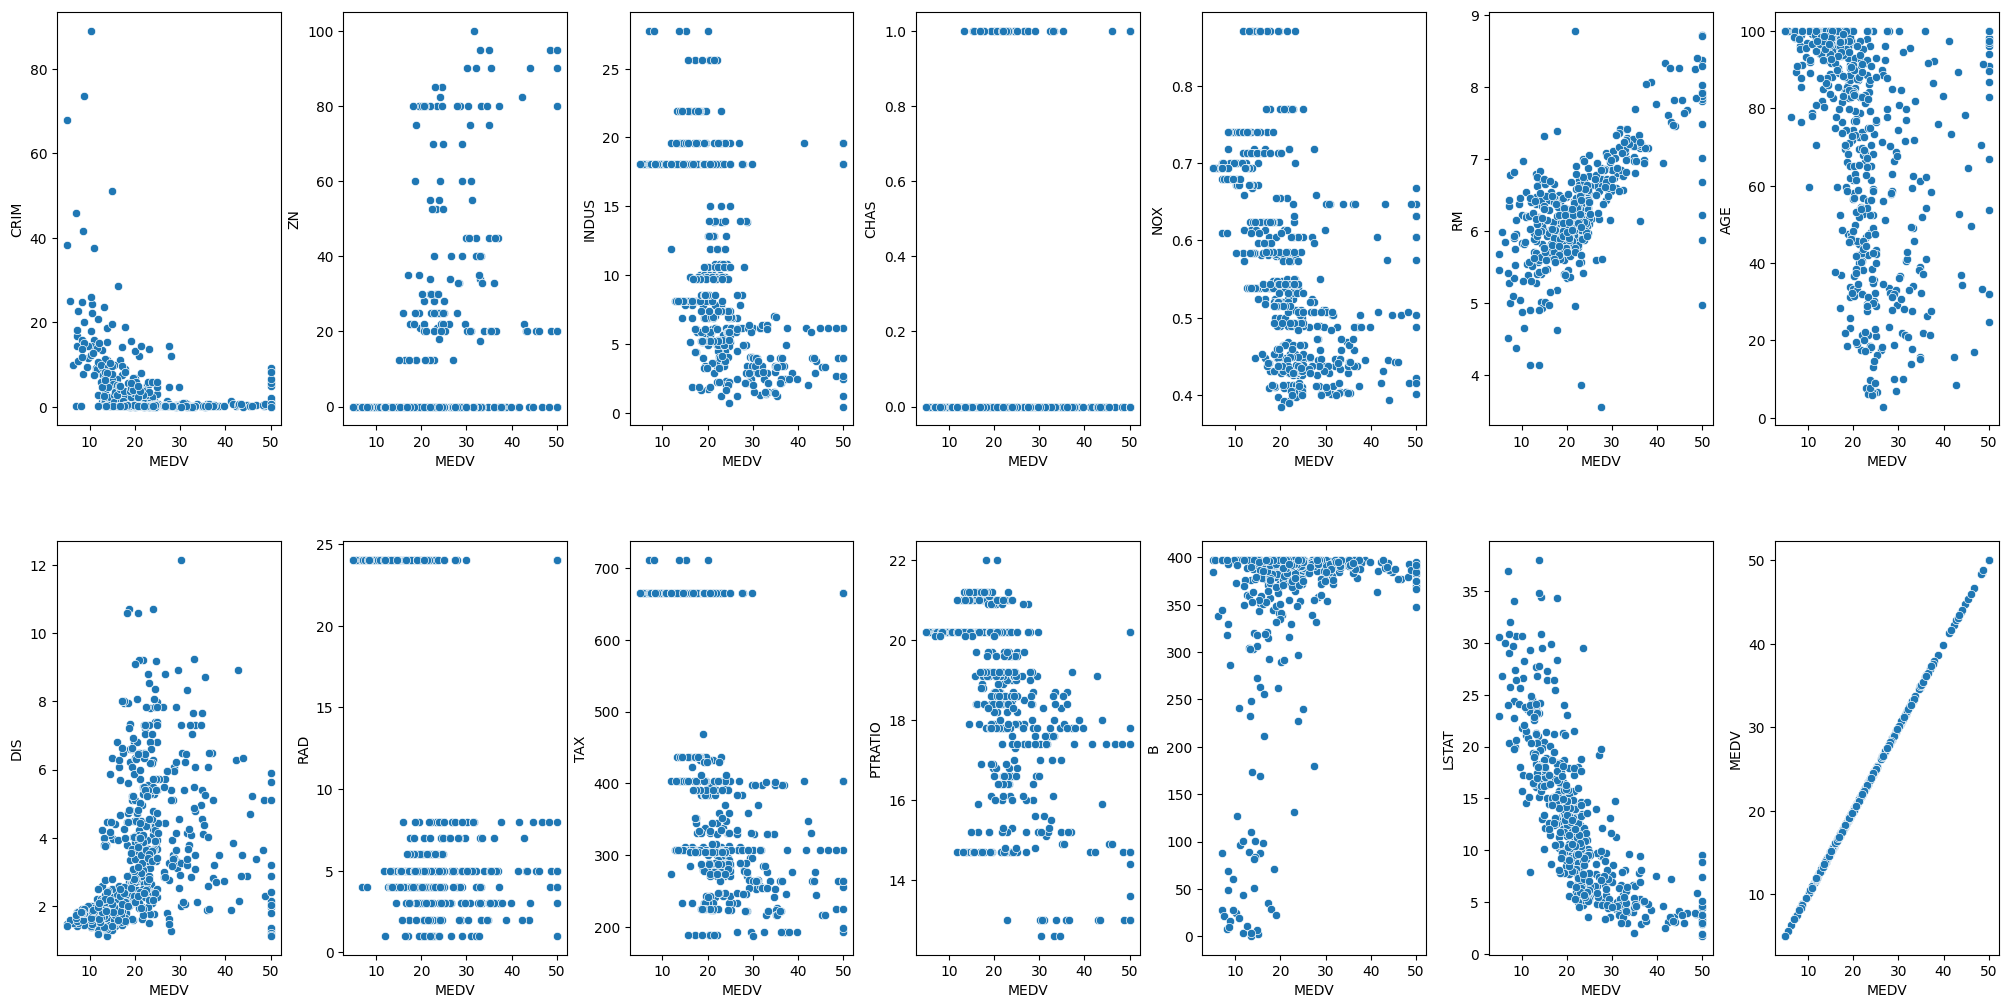

In [7]:
fig, axs = plt.subplots(ncols=7, nrows=2, figsize=(20, 10))
index = 0
axs = axs.flatten()
for k,v in df.items():
    sns.scatterplot(x='MEDV', y=k, data=df, ax=axs[index])
    index += 1
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=5.0)

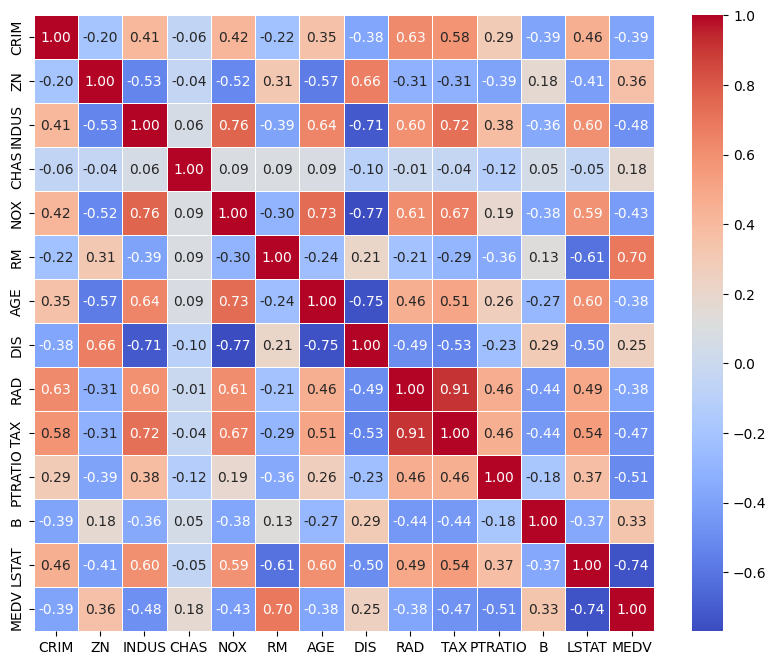

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5);

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
df.drop(columns = "MEDV"),
df['MEDV'],
train_size=0.75,
random_state = 123
)
# Creación del modelo
# ------------------------------------------------------------------------------
modelo = DecisionTreeRegressor(
random_state = 123
)
# Entrenamiento del modelo
# ------------------------------------------------------------------------------
modelo.fit(X_train, y_train)


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",123
,"max_

Profundidad del árbol: 17
Número de hojas del árbol: 355
Parámetros usados en el entrenamiento: {'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 123, 'splitter': 'best'}


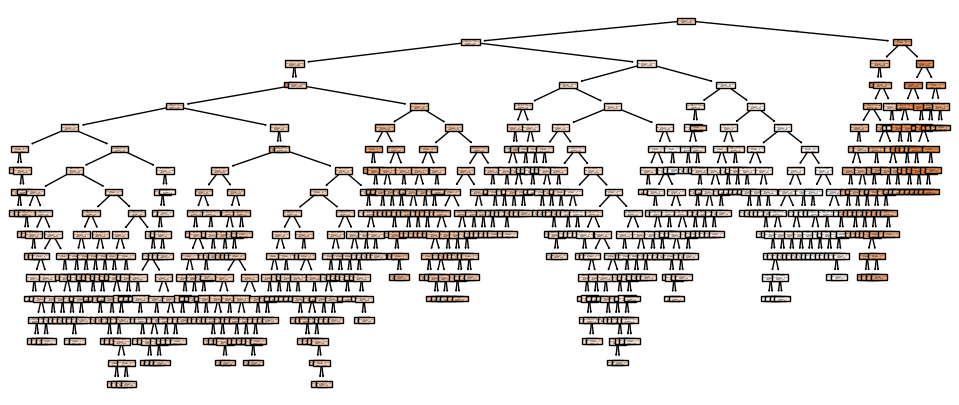

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
tree.plot_tree(
decision_tree = modelo,
feature_names = df.drop(columns = "MEDV").columns,
class_names = ['MEDV'],
filled = True
);
print(f'Profundidad del árbol: {modelo.get_depth()}')
print(f'Número de hojas del árbol: {modelo.get_n_leaves()}')
print(f'Parámetros usados en el entrenamiento: {modelo.get_params()}')

In [11]:
rmse = np.sqrt(mean_squared_error(y_test, modelo.predict(X_test)))
print(f"RMSE: {rmse:.2f} * 10k", "Variacion del valor de la vivienta en miles de dolares")


RMSE: 6.52 * 10k Variacion del valor de la vivienta en miles de dolares


In [12]:
importancia_predictores = pd.DataFrame(
{'predictor': df.drop(columns = "MEDV").columns,
'importancia': modelo.feature_importances_}
)
print("Importancia de los predictores en el modelo")
print("-------------------------------------------")
importancia_predictores.sort_values('importancia', ascending=False)

Importancia de los predictores en el modelo
-------------------------------------------


,predictor,importancia
5,RM,0.614705
12,LSTAT,0.212712
7,DIS,0.060532
0,CRIM,0.041059
4,NOX,0.020197
10,PTRATIO,0.014584
2,INDUS,0.009163
11,B,0.008723
9,TAX,0.008403
6,AGE,0.007306


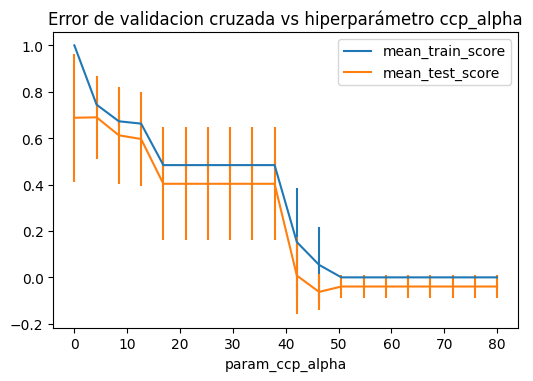

In [13]:
# Pruning (const complexity pruning) por validación cruzada
# ------------------------------------------------------------------------------
# Valores de ccp_alpha evaluados
param_grid = {'ccp_alpha':np.linspace(0, 80, 20)}
# Búsqueda por validación cruzada
grid = GridSearchCV(
# El árbol se crece al máximo posible para luego aplicar el pruning
    estimator = DecisionTreeRegressor(
                                    max_depth = None,
                                    random_state = 123
                                    ),
    param_grid = param_grid,
    cv = 10,
    refit = True,
    return_train_score = True
)
grid.fit(X_train, y_train)
fig, ax = plt.subplots(figsize=(6, 3.84))
scores = pd.DataFrame(grid.cv_results_)
scores.plot(x='param_ccp_alpha', y='mean_train_score', yerr='std_train_score',ax=ax)
scores.plot(x='param_ccp_alpha', y='mean_test_score', yerr='std_test_score',ax=ax)
ax.set_title("Error de validacion cruzada vs hiperparámetro ccp_alpha");


In [14]:
# Mejor valor ccp_alpha encontrado
# ------------------------------------------------------------------------------
grid.best_params_.items()

dict_items([('ccp_alpha', np.float64(4.2105263157894735))])

In [15]:
# Creación del modelo
# ------------------------------------------------------------------------------
modelo1 = DecisionTreeRegressor(
            ccp_alpha = grid.best_params_['ccp_alpha'],
            random_state = 123
)
# Entrenamiento del modelo
# ------------------------------------------------------------------------------
modelo1.fit(X_train, y_train)
rmse = np.sqrt(mean_squared_error(y_test, modelo1.predict(X_test)))
print(f"RMSE: {rmse:.2f} * 10k", "Variacion del valor de la vivienta en miles de dolares")
print(f'Profundidad del árbol: {modelo1.get_depth()}')
print(f'Número de hojas del árbol: {modelo1.get_n_leaves()}')
print(f'Parámetros usados en el entrenamiento: {modelo1.get_params()}')

RMSE: 5.92 * 10k Variacion del valor de la vivienta en miles de dolares
Profundidad del árbol: 2
Número de hojas del árbol: 4
Parámetros usados en el entrenamiento: {'ccp_alpha': np.float64(4.2105263157894735), 'criterion': 'squared_error', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 123, 'splitter': 'best'}


Profundidad del árbol: 2
Número de nodos terminales: 4


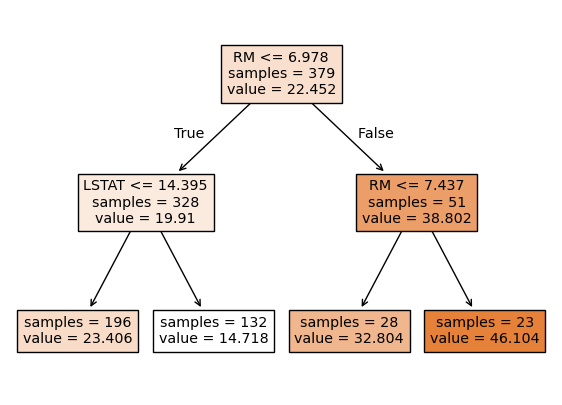

In [16]:
# Estructura del árbol final
# ------------------------------------------------------------------------------
modelo_final = grid.best_estimator_
print(f"Profundidad del árbol: {modelo_final.get_depth()}")
print(f"Número de nodos terminales: {modelo_final.get_n_leaves()}")
fig, ax = plt.subplots(figsize=(7, 5))
tree. plot_tree(
            decision_tree = modelo_final,
            feature_names = df.drop(columns = "MEDV").columns,
            class_names = ['MEDV'],
            filled = True,
            impurity = False,
            ax = ax
);


In [18]:
# Error de test del modelo inicial
#-------------------------------------------------------------------------------
predicciones = modelo.predict(X = X_test)
from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(
        y_true = y_test,
        y_pred = predicciones
)
print(f"El error (rmse) de test es: {rmse}")

El error (rmse) de test es: 6.518242118467266


In [19]:
# Error de test del modelo final (tras aplicar pruning)
#-------------------------------------------------------------------------------
predicciones = modelo_final.predict(X = X_test)
rmse = root_mean_squared_error(
    y_true = y_test,
    y_pred = predicciones
)
print(f"El error (rmse) de test es: {rmse}")

El error (rmse) de test es: 5.91713823276661


In [20]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
# Definir las particiones
kf = KFold(n_splits=5, shuffle=True, random_state=0) #! 5 particiones,barajando los datos y con semilla fija para reproducibilidad
train_rmses = []
val_rmses = []
# Validación cruzada
for train_idx, val_idx in kf.split(X_train):
    xtr, xvl = X_train.iloc[train_idx], X_train.iloc[val_idx]
    ytr, yvl = y_train.iloc[train_idx], y_train.iloc[val_idx]
    # Entrenar el modelo
    arbol = DecisionTreeRegressor(random_state=123)
    arbol.fit(xtr, ytr)
    # Calcular desempeño
    train_rmse = np.sqrt(mean_squared_error(ytr, arbol.predict(xtr)))
    val_rmse = np.sqrt(mean_squared_error(yvl, arbol.predict(xvl)))
    train_rmses.append(train_rmse)
    val_rmses.append(val_rmse)
# Imprimir resultados
print(f"RMSE promedio entrenamiento: {np.mean(train_rmses):.4f}")
print(f"RMSE promedio validación: {np.mean(val_rmses):.4f}")

RMSE promedio entrenamiento: 0.0000
RMSE promedio validación: 5.0192


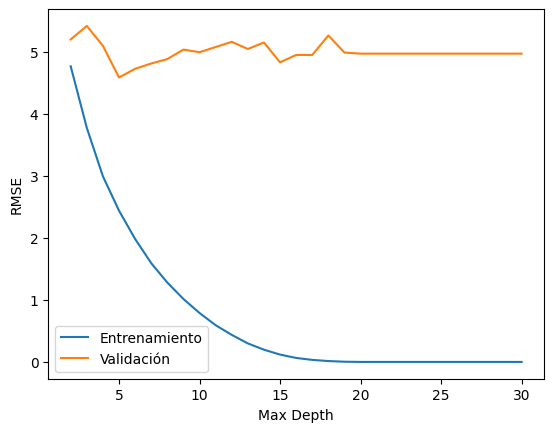

In [21]:
# Particiones
kf = KFold(n_splits=5, shuffle=True, random_state=0)
# Inicializar listados
MAX_DEPTHS = np.arange(2,31)
MEAN_TRAIN_RMSES = []
MEAN_VAL_RMSES = []
# Validación cruzada por cada "max_depth"
for max_depth in MAX_DEPTHS:
    train_rmses = []
    val_rmses = []
    for train_idx, val_idx in kf.split(X_train):
        xtr, xvl = X_train.iloc[train_idx], X_train.iloc[val_idx]
        ytr, yvl = y_train.iloc[train_idx], y_train.iloc[val_idx]
        # Entrenar el modelo
        arbol = DecisionTreeRegressor(max_depth=max_depth, random_state=0)
        arbol.fit(xtr, ytr)
        # Calcular desempeño
        train_rmse = np.sqrt(mean_squared_error(ytr, arbol.predict(xtr)))
        val_rmse = np.sqrt(mean_squared_error(yvl, arbol.predict(xvl)))
        train_rmses.append(train_rmse)
        val_rmses.append(val_rmse)
    MEAN_TRAIN_RMSES.append(np.mean(train_rmses))
    MEAN_VAL_RMSES.append(np.mean(val_rmses))
# Graficar MEAN_TRAIN_RMSES y MEAN_VAL_RMSES vs. MAX_DEPTHS
plt.plot(MAX_DEPTHS, MEAN_TRAIN_RMSES, label='Entrenamiento')
plt.plot(MAX_DEPTHS, MEAN_VAL_RMSES, label='Validación')
plt.xlabel('Max Depth')
plt.ylabel('RMSE')
plt.legend();


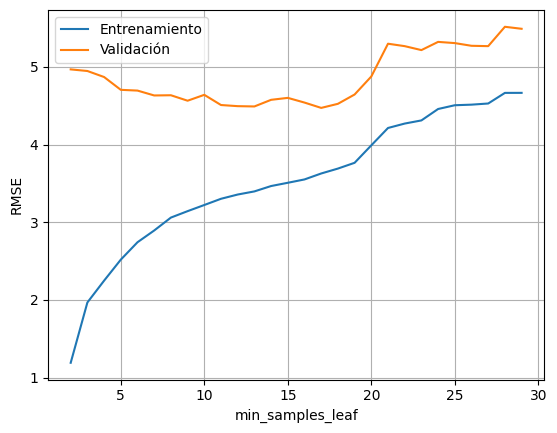

In [22]:
# Veamos el efecto que tiene "min_samples_leaf":
kf = KFold(n_splits=5, shuffle=True, random_state=0)
# Inicializar listados
MIN_SAMPLES_LEAF = np.arange(2,30)
MEAN_TRAIN_RMSES = []
MEAN_VAL_RMSES = []
for min_samples_leaf in MIN_SAMPLES_LEAF:
    train_rmses = []
    val_rmses = []
    for train_idx, val_idx in kf.split(X_train):
        xtr, xvl = X_train.iloc[train_idx], X_train.iloc[val_idx]
        ytr, yvl = y_train.iloc[train_idx], y_train.iloc[val_idx]
        # Entrenar el modelo
        arbol = DecisionTreeRegressor(min_samples_leaf=min_samples_leaf, random_state=0)
        arbol.fit(xtr, ytr)
        # Calcular desempeño
        train_rmse = np.sqrt(mean_squared_error(ytr, arbol.predict(xtr)))
        val_rmse = np.sqrt(mean_squared_error(yvl, arbol.predict(xvl)))
        train_rmses.append(train_rmse)
        val_rmses.append(val_rmse)
    MEAN_TRAIN_RMSES.append(np.mean(train_rmses))
    MEAN_VAL_RMSES.append(np.mean(val_rmses))
# Graficar MEAN_TRAIN_RMSES y MEAN_VAL_RMSES vs. MAX_DEPTHS
plt.plot(MIN_SAMPLES_LEAF, MEAN_TRAIN_RMSES, label='Entrenamiento')
plt.plot(MIN_SAMPLES_LEAF, MEAN_VAL_RMSES, label='Validación')
plt.grid(True)
plt.xlabel('min_samples_leaf')
plt.ylabel('RMSE')
plt.legend();


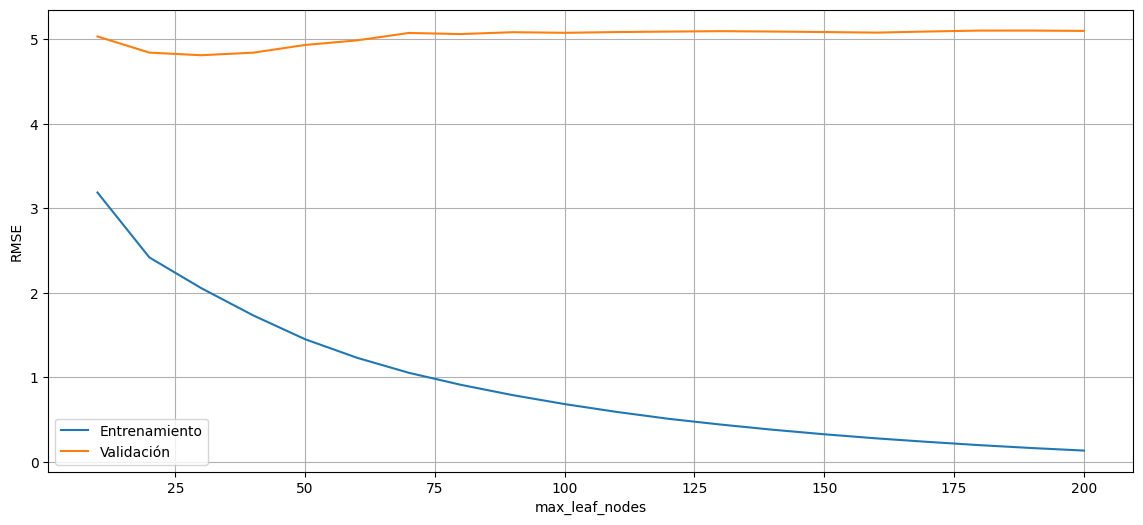

In [23]:
 # Hagamos algo similar pero con "max_leaf_nodes" (máximo número de hojas):
kf = KFold(n_splits=5, shuffle=True, random_state=0)
# Inicializar listados
MAX_LEAF_NODES = np.arange(10,201,10)
MEAN_TRAIN_RMSES = []
MEAN_VAL_RMSES = []
for max_leaf_nodes in MAX_LEAF_NODES:
    train_rmses = []
    val_rmses = []
    for train_idx, val_idx in kf.split(X_train):
        xtr, xvl = X_train.iloc[train_idx], X_train.iloc[val_idx]
        ytr, yvl = y_train.iloc[train_idx], y_train.iloc[val_idx]
        # Entrenar el modelo
        arbol = DecisionTreeRegressor(max_leaf_nodes=max_leaf_nodes, random_state=0)
        arbol.fit(xtr, ytr)
        # Calcular desempeño
        train_rmse = np.sqrt(mean_squared_error(ytr, arbol.predict(xtr)))
        val_rmse = np.sqrt(mean_squared_error(yvl, arbol.predict(xvl)))
        train_rmses.append(train_rmse)
        val_rmses.append(val_rmse)
    MEAN_TRAIN_RMSES.append(np.mean(train_rmses))
    MEAN_VAL_RMSES.append(np.mean(val_rmses))
# Graficar MEAN_TRAIN_RMSES y MEAN_VAL_RMSES vs. MAX_DEPTHS
plt.figure(figsize=(14, 6))
plt.plot(MAX_LEAF_NODES, MEAN_TRAIN_RMSES, label='Entrenamiento')
plt.plot(MAX_LEAF_NODES, MEAN_VAL_RMSES, label='Validación')
# plt.xticks(np.arange(1, 200, 2))
plt.grid(True)
plt.xlabel('max_leaf_nodes')
plt.ylabel('RMSE')
plt.legend();

In [24]:
arbol = DecisionTreeRegressor(max_depth=4, min_samples_leaf=27,max_leaf_nodes=9, random_state=123)
arbol.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",27
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",123
,"max_le

In [25]:
# Calcular desempeño
train_rmse = np.sqrt(mean_squared_error(y_test, arbol.predict(X_test)))
val_rmse = np.sqrt(mean_squared_error(y_train, arbol.predict(X_train)))
print(f'RMSE entrenamiento: {train_rmse}')
print(f'RMSE validación: {val_rmse}')


RMSE entrenamiento: 5.4062624794230825
RMSE validación: 4.640319871989437


In [26]:
print(f'Profundidad del árbol: {arbol.get_depth()}')
print(f'Número de hojas del árbol: {arbol.get_n_leaves()}')
print(f'Parámetros usados en el entrenamiento: {arbol.get_params()}')

Profundidad del árbol: 4
Número de hojas del árbol: 8
Parámetros usados en el entrenamiento: {'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 4, 'max_features': None, 'max_leaf_nodes': 9, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 27, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 123, 'splitter': 'best'}


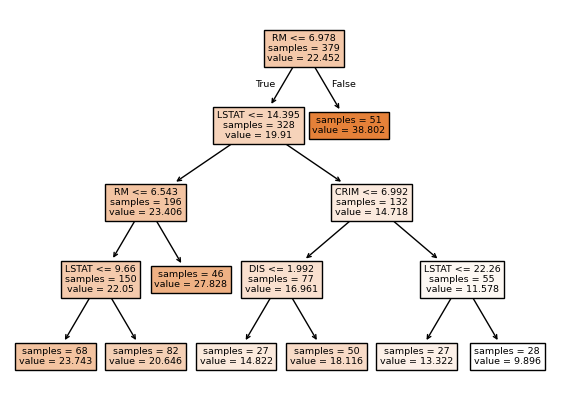

In [27]:
fig, ax = plt.subplots(figsize=(7, 5))
tree. plot_tree(
    decision_tree = arbol,
    feature_names = df.drop(columns = "MEDV").columns,
    class_names = ['MEDV'],
    filled = True,
    impurity = False,
    ax = ax
);
